![MSE Logo](https://moodle.msengineering.ch/pluginfile.php/1/core_admin/logo/0x150/1643104191/logo-mse.png)

# AdvNLP Lab 1: Text Tokenization


The goal of this lab is to perform tokenization of texts using the [NLTK](http://www.nltk.org/) toolkit or using BPE from [SentencePiece](https://github.com/google/sentencepiece).  You will use the environment that you set up following the instructions of the introductory Jupyter notebook.  

You will use NLTK functions to get texts from the web and segment (split) them into sentences and words (also called *tokens*).  You will experiment with extracting statistics about the frequencies of tokens, and compare statistics for a novel and an undeciphered manuscript. 

To submit your work, please execute all cells of this notebook, save it, and submit it as homework on Moodle.

## 1. Using NLTK to download and tokenize a text

Please install NLTK (the Natural Language Processing Toolkit) by following the installation instructions at the [NLTK website](http://www.nltk.org/install.html).  To use NLTK, first `import nltk`.  NLTK has a download manager (try `nltk.download()` in command line) which can import several resources, including corpora.

To get started, look at [Chapter 1](http://www.nltk.org/book/ch01.html) of the [online NLTK book (NLP with Python)](http://www.nltk.org/book/) and use the commands there as a model.  <span style="color:gray">Note: the online book was updated for Python 3, but the [printed book](http://shop.oreilly.com/product/9780596516499.do) is only for Python 2.</span> 

**1a.** Using inspiration from [Chapter 3 (3.1. Processing Raw Text) of the NLTK book](http://www.nltk.org/book/ch03.html), download a book from the Gutenberg Project in text format. What is its size? Are these bytes or characters? <span style="color:gray">Note: to learn more about special characters, you can refer to Python's documentation of [Unicode support](https://docs.python.org/3/howto/unicode.html).</span>

In [56]:
from urllib import request # you may need to run first:  !pip install urllib

In [57]:
# Please write your Python code below and execute it.
import nltk
import re
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np 
import scipy
import sentencepiece as spm
nltk.download('punkt') 
nltk.download('punkt_tab') 



url = "http://www.gutenberg.org/files/2554/2554-0.txt"
response = request.urlopen(url)
raw = response.read().decode('utf8')

if isinstance(raw, str):
    print("Text is characters")
elif isinstance(raw, bytes):
    print("Text is bytes")
print(f"Len raw text: {len(raw)}\n")
raw[:1000]

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/nathanmassicot/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/nathanmassicot/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Text is characters
Len raw text: 1135213



'*** START OF THE PROJECT GUTENBERG EBOOK 2554 ***\n\n\n\n\nCRIME AND PUNISHMENT\n\nBy Fyodor Dostoevsky\n\n\n\nTranslated By Constance Garnett\n\n\n\n\nTRANSLATOR’S PREFACE\n\nA few words about Dostoevsky himself may help the English reader to\nunderstand his work.\n\nDostoevsky was the son of a doctor. His parents were very hard-working\nand deeply religious people, but so poor that they lived with their five\nchildren in only two rooms. The father and mother spent their evenings\nin reading aloud to their children, generally from books of a serious\ncharacter.\n\nThough always sickly and delicate Dostoevsky came out third in the\nfinal examination of the Petersburg school of Engineering. There he had\nalready begun his first work, “Poor Folk.”\n\nThis story was published by the poet Nekrassov in his review and\nwas received with acclamations. The shy, unknown youth found himself\ninstantly something of a celebrity. A brilliant and successful career\nseemed to open before him, but th

**Answer** : So as we can see the size of "raw" is 1135213 character 

**1b.** We want to keep only the original text of the book, without the header, preface, or license.  Please determine (e.g. by locating the position of initial and final strings) how much your should trim from the beginning and from the end in order to keep only the original text of the book (including titles). Please remove unnecessary paragraph marks (e.g. if the text is segmented into fixed-length lines). Save the result as a new string and display its length.

In [58]:
# Please write your Python code below and execute it.
preface_start = raw.find("CRIME AND PUNISHMENT")
start = raw.find("CRIME AND PUNISHMENT", preface_start + 1)
end = raw.rfind("*** END OF THE PROJECT GUTENBERG EBOOK 2554 ***")
original_text_only = raw[start:end]

cleaned = " ".join(original_text_only.splitlines()) # Removes both artificial newlines as well as original paragraphs (\n\n). 
cleaned = re.sub(r" +", " ", cleaned)

print(f"Len cleaned: {len(cleaned)}\n")
print(cleaned[:1000])

Len cleaned: 1126367

CRIME AND PUNISHMENT PART I CHAPTER I On an exceptionally hot evening early in July a young man came out of the garret in which he lodged in S. Place and walked slowly, as though in hesitation, towards K. bridge. He had successfully avoided meeting his landlady on the staircase. His garret was under the roof of a high, five-storied house and was more like a cupboard than a room. The landlady who provided him with garret, dinners, and attendance, lived on the floor below, and every time he went out he was obliged to pass her kitchen, the door of which invariably stood open. And each time he passed, the young man had a sick, frightened feeling, which made him scowl and feel ashamed. He was hopelessly in debt to his landlady, and was afraid of meeting her. This was not because he was cowardly and abject, quite the contrary; but for some time past he had been in an overstrained irritable condition, verging on hypochondria. He had become so completely absorbed in himse

In [59]:
cleaned = cleaned.replace("...", "") # Ellipsis (...) doesn't get treated consistently, sometimes creates new sentence and sometimes not.
cleaned = cleaned.replace("—", " ")
cleaned = cleaned.replace("“", '"').replace("”", '"').replace("’", "'").replace("‘", "'")

**1c.** NLTK defines a function to segment a text into sentences (`nltk.sent_tokenize(...)` (documented [here](https://www.nltk.org/api/nltk.tokenize.html#nltk.tokenize.word_tokenize))) and another one to tokenize a text into words (`nltk.word_tokenize(...)` (documented [here](https://www.nltk.org/api/nltk.tokenize.html#nltk.tokenize.sent_tokenize))). <span style="color:gray">Note: NLTK calls the first one "sentence tokenization", which is unusual.</span>

Please segment the text above into sentences with NLTK, display the number of sentences, and display five sentences of your choice.  Please assess briefly the quality of the segmentation.  If you think that some special characters degrade the results, please go back and remove or replace them in the full text.

In [60]:
# Please write your Python code in this cell and execute it.

cleaned_sentence = nltk.sent_tokenize(cleaned)
print(f"Num sentences: {len(cleaned_sentence)}")

for s in cleaned_sentence[:3]:
    print(s)

for s in cleaned_sentence[149:151]:
    print(s)

Num sentences: 14996
CRIME AND PUNISHMENT PART I CHAPTER I On an exceptionally hot evening early in July a young man came out of the garret in which he lodged in S. Place and walked slowly, as though in hesitation, towards K. bridge.
He had successfully avoided meeting his landlady on the staircase.
His garret was under the roof of a high, five-storied house and was more like a cupboard than a room.
No, it's nonsense, it's rubbish!"
he added resolutely.


**Student assessment of segmentation quality:**

After removing ellipsis the segmentation if more consistent, at the cost of losing some semantic information.

The first segmented sentence contains both the book title and the chapter number, as they have no punctuation. It can be argued that these should be separate sentences, although they are special cases as they are not complete sentences in and of themselves.

Abbreviations like S. and K. (as seen in the first sentence) are correctly _not_ causing segmentation.

Sentences that are a mix of narration and dialog get split, eg:

**No, it's nonsense, it's rubbish!"

he added resolutely.**

It can be argued that this should be a single sentence.

**1d.** Please save the resulting text into a file, one sentence per line.

In [61]:
# Please write your Python code in this cell and execute it.
output_path = "Cleaned_sentence.text"
with open(output_path, "w") as f:
    for sentence in cleaned_sentence:
        f.write(sentence + "\n")

print(f" {len(cleaned_sentence)} Cleaned sentences have been written to {output_path}")

 14996 Cleaned sentences have been written to Cleaned_sentence.text


**1e.** Please segment each sentence into tokens,  store the result in a new variable (a list of lists), and display the same five sentences as above.  Please comment briefly on the quality of the tokenization.

In [62]:
# Please write your Python code in this cell and execute it.
tokenized_sentence = []

for sentence in cleaned_sentence:
    sentence = nltk.word_tokenize(sentence, preserve_line=True)
    tokenized_sentence.append(sentence)

for s in tokenized_sentence[:3]:
    print(s)

for s in tokenized_sentence[149:151]:
    print(s)

['CRIME', 'AND', 'PUNISHMENT', 'PART', 'I', 'CHAPTER', 'I', 'On', 'an', 'exceptionally', 'hot', 'evening', 'early', 'in', 'July', 'a', 'young', 'man', 'came', 'out', 'of', 'the', 'garret', 'in', 'which', 'he', 'lodged', 'in', 'S.', 'Place', 'and', 'walked', 'slowly', ',', 'as', 'though', 'in', 'hesitation', ',', 'towards', 'K.', 'bridge', '.']
['He', 'had', 'successfully', 'avoided', 'meeting', 'his', 'landlady', 'on', 'the', 'staircase', '.']
['His', 'garret', 'was', 'under', 'the', 'roof', 'of', 'a', 'high', ',', 'five-storied', 'house', 'and', 'was', 'more', 'like', 'a', 'cupboard', 'than', 'a', 'room', '.']
['No', ',', 'it', "'s", 'nonsense', ',', 'it', "'s", 'rubbish', '!', "''"]
['he', 'added', 'resolutely', '.']


**Student assessment of tokenization quality:**

The tokenizer distinguishes between punctuation used for abbreviations and sentence ending, ie. "S." vs "." which is arguably desirable.

Hyphenated words, like "five-storied", are kept as single tokens, which is arguably desirable. 

Contracted words, like "it's" gets tokenized into "it" and "'s" which may or may not be desirable. 


**1f.** Please display the total number of tokens found in the text by this method (sentence segmentation followed by sentence-level tokenization).

In [63]:
# Please write your Python code in this cell and execute it.
print(f"Total num tokens: {sum(len(s) for s in tokenized_sentence)}") 

Total num tokens: 248602


**1g.** Please tokenize now directly the initial full text, without segmenting it into sentences.  Please display the total number of tokens found, and compare this number with the one obtained above.

In [64]:
# Please write your Python code in this cell and execute it.
direct_tokenized_text = nltk.word_tokenize(cleaned)
len(direct_tokenized_text)

248602

There is no difference of token between the two methods, as word tokenizer calls the sentence tokenizer first internally.

## 2. Computing lexical statistics 

**2a.** Please determine the size of the vocabulary of your text (the number of unique *types*) by converting the list of tokens to a Python `set`.  Note that these *types* include punctuations and other symbols found through tokenization, and that uppercase/lowercase letters are different.

In [65]:
# Please write your Python code in this cell and execute it.
set_tokenized_sentence = set()
for sentence in tokenized_sentence :
    for token in sentence:
        set_tokenized_sentence.add(token)

print(list(set_tokenized_sentence)[:10])       
print("The size of the vocabulary is:", len(set_tokenized_sentence))

['swoon', 'nowadays', 'exasperation', 'rugs', 'join', 'Cristal', 'inhumanly', 'cup', 'murderers', 'influences']
The size of the vocabulary is: 10632


**2b.** What is the type-to-token ratio (TTR) of your text?

In [66]:
# Please write your Python code in this cell and execute it.
TTR = len(set_tokenized_sentence) / len(direct_tokenized_text)
print("Type-Token Ratio (TTR):", TTR)

Type-Token Ratio (TTR): 0.042767153924747184


**2c.** Please create a `nltk.Text` object from the tokenized version of your text, without the sentence segmentation.  Such an object will enable you to compute statistics using NLTK functions.  [Chapter 1 of the NLTK book](http://www.nltk.org/book/ch01.html) provides examples of use.

<span style="color:gray">Note: `nltk.word_tokenize()` and `nltk.sent_tokenize()` apply to strings but not directly to `ntlk.Text` objects.  A `nltk.Text` object can store either a string, or a list of words, or a list of sentences (list of lists of strings).</span>

In [67]:
# Please write your Python code in this cell and execute it.
flat_tokenized_sentence = [token for sentence in tokenized_sentence for token in sentence]

book_text = nltk.Text(flat_tokenized_sentence)

print(type(book_text))
print("Nb tokens:", len(book_text))
print(book_text[:30])  # aperçu


<class 'nltk.text.Text'>
Nb tokens: 248602
['CRIME', 'AND', 'PUNISHMENT', 'PART', 'I', 'CHAPTER', 'I', 'On', 'an', 'exceptionally', 'hot', 'evening', 'early', 'in', 'July', 'a', 'young', 'man', 'came', 'out', 'of', 'the', 'garret', 'in', 'which', 'he', 'lodged', 'in', 'S.', 'Place']


**2d.** Please construct the frequency distribution of your text, which is an object of the `nltk.FreqDist`class, instantiated directly from the `nltk.Text` object containing the list of all words. See [Sec. 3.1 of Ch. 1 of the NLTK book](http://www.nltk.org/book/ch01.html#frequency-distributions).  Using the `most_common` method on the `FreqDist` object, find the 50 most frequent words in your text, and display among them the words that have at least 4 characters.  Please comment briefly on the results.

In [68]:
# Please write your Python code in this cell and execute it.
fdist1 = nltk.FreqDist(book_text)
print(fdist1)

top_50 = fdist1.most_common(50)
long_words = [(word, freq) for word, freq in top_50 if len(word) >= 4]
print(long_words)


<FreqDist with 10632 samples and 248602 outcomes>
[('that', 3047), ('with', 1672), ('have', 1134), ('Raskolnikov', 783), ('what', 753), ('were', 706), ('from', 696)]


**Student comment:**

The 50 most frequent words (tokens) are dominated by short words and punctuation. Only 7 of them have 4 or more letters.

## 3. Testing Zipf's law on a book

[Zipf's law](https://en.wikipedia.org/wiki/Zipf%27s_law) formalizes the following empirical observation for large texts or collections: when ranking word types by decreasing frequencies, the ranks *x* (i.e. 1, 2, 3, ...) and the numbers of occurrences *y* (e.g. 948, 321, 146, ...) of each word are related approximately by the formula *y = a / x^b*.  The parameters *a* and *b* depend on the text.  If plotted in log-log coordinates, this relation results in a linear plot (because log(*y*) = *a* - *b* log(*x*)).

**3a.** Using the `FreqDist` object, please collect the frequencies of the 1000 most frequent words, rank them by decreasing values, and plot the (*rank*, *frequency*) curve on a log-log scale by setting the `.xscale("log")` and `.yscale("log")` parameters of the plot.

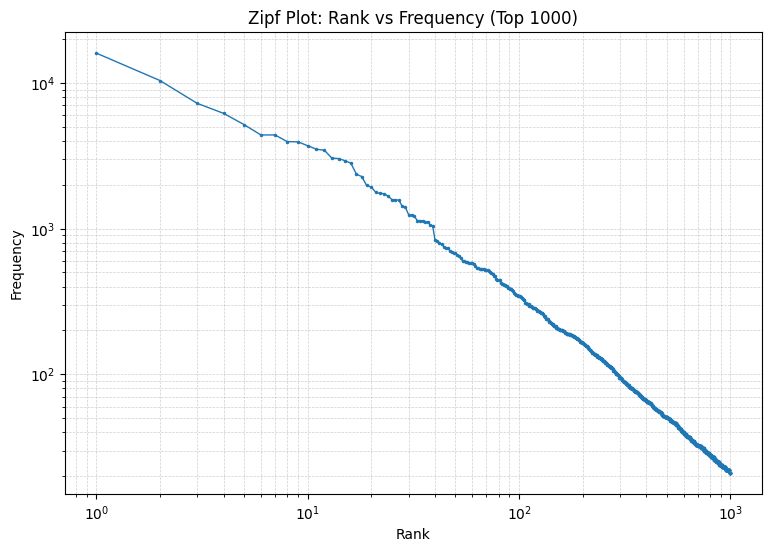

In [69]:
# Please write your Python code in this cell and execute it.


top_1000 = fdist1.most_common(1000)

ranks = list(range(1, len(top_1000) + 1))
freqs = [freq for _, freq in top_1000]


plt.figure(figsize=(9, 6))
plt.plot(ranks, freqs, marker=".", linestyle="-", linewidth=1, markersize=3)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf Plot: Rank vs Frequency (Top 1000)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.6)
plt.show()


**3b.** Please find the values of *a* and *b* which lead to the closest matching between the observation curve (*rank*, *frequency*) and Zipf's curve (*x*, *y = a / x^b*).  You can use `scipy.optimize.curve_fit()` or even a trial-and-error approach.  Please display both curves on the same graph with a log-log scale to visualize how close they are.  Please also display the optimal values of *a* and *b*.

Optimal a = 17257.222037
Optimal b = 0.790023


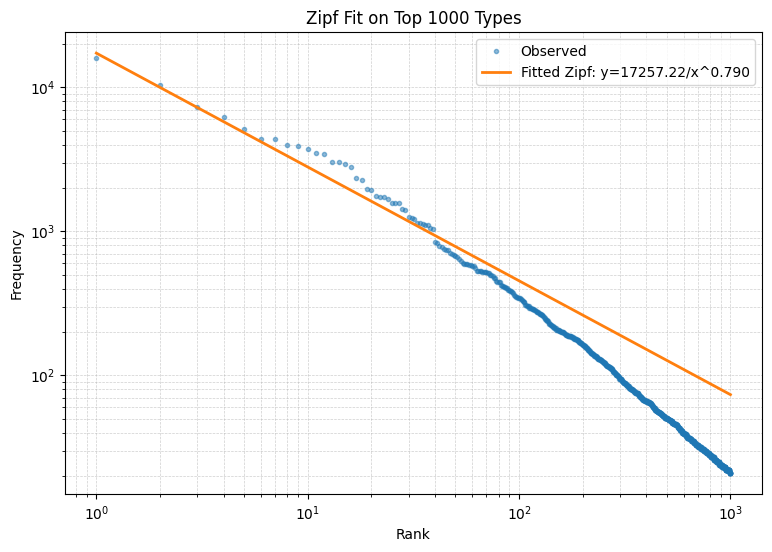

In [70]:
def zipf(x, a, b):
    return a / (x ** b)

p0 = (freqs[0], 1.0) 
(params, cov) = scipy.optimize.curve_fit(zipf, ranks, freqs, p0=p0, bounds=(0, np.inf))
a_opt, b_opt = params

freqs_fit = zipf(ranks, a_opt, b_opt)


print(f"Optimal a = {a_opt:.6f}")
print(f"Optimal b = {b_opt:.6f}")


plt.figure(figsize=(9, 6))
plt.plot(ranks, freqs, "o", markersize=3, alpha=0.5, label="Observed")
plt.plot(ranks, freqs_fit, "-", linewidth=2, label=f"Fitted Zipf: y={a_opt:.2f}/x^{b_opt:.3f}")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf Fit on Top 1000 Types")
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.6)
plt.legend()
plt.show()



**3c.** Based on the graph, can you conclude that the frequencies of tokens in the text you select corroborate Zipf's law, or rather contradict it?

In [71]:
# Please write your answer in this cell.
print("The graph corroborates Zipf's law as the observed \nand fitted lines are quite aligned")

The graph corroborates Zipf's law as the observed 
and fitted lines are quite aligned


## 4.  Does an undeciphered manuscript obey Zipf's law?

The [Voynich manuscript](https://en.wikipedia.org/wiki/Voynich_manuscript) is an undeciphered manuscript from the 15th century.   Its script and language are still unknown, and it may even be a hoax.  You can read more about it at [Voynich.nu](http://www.voynich.nu/), which provides pictures and transcriptions.  A version of it converted to ASCII characters (corresponding to symbols from the manuscript) and tokenized with one word per line is made available for this lab as `voynich.txt`.

**4a.** Please compute the number of tokens, the number of types, and the type-to-token ration (TTR) for this document.  How does it compare with your previous text?

Let's do a function because were are going to do the same task afterward 

In [72]:


def lexical_stats(text_or_tokens, tokenizer=nltk.word_tokenize):
    """
    Returns: dict(tokens, types, ttr, vocab)
    - text_or_tokens: raw text (str) OR already-tokenized list
    - tokenizer: used only if input is a str
    """
    if isinstance(text_or_tokens, str):
        tokens = nltk.word_tokenize(text_or_tokens)
    else:
        tokens = list(text_or_tokens)

    vocab = set(tokens)
    n_tokens = len(tokens)
    n_types = len(vocab)
    ttr = (n_types / n_tokens) if n_tokens else 0.0

    return {"tokens": n_tokens, "types": n_types, "ttr": ttr, "vocab": vocab}

def print_stats(name, stats):
    print(f"{name} -> tokens: {stats['tokens']}, types: {stats['types']}, TTR: {stats['ttr']:.4f}")


In [73]:
# Please write your Python code in this cell and execute it.
with open("voynich.txt", encoding="utf-8") as f:
    voynich_tokens = [line.strip() for line in f ]
    
print(type(voynich_tokens))  

voynich_stats = lexical_stats(voynich_tokens) #test then tokenized with the function
gutenberg_stats = lexical_stats(cleaned)  # same 
print_stats("Voynich", voynich_stats)
print_stats("Gutenberg", gutenberg_stats)

<class 'list'>
Voynich -> tokens: 21029, types: 5674, TTR: 0.2698
Gutenberg -> tokens: 248602, types: 10632, TTR: 0.0428


**Answer:** The Voynich text has a much higher TTR, but this is expected because it is a much shorter text

**4b.** Considering the 1000 most frequent tokens of the Voynich manuscript, do they follow Zipf's law?  Please also display the optimal values of *a* and *b* and the mean absolute percentage error. 

In [74]:
# Please write your Python code in this cell and execute it.
voynich_text = nltk.Text(voynich_tokens)
voynich_fdist = nltk.FreqDist(voynich_text)

mostcommon_voynich_fdist = voynich_fdist.most_common(1000)

print(mostcommon_voynich_fdist)


[('8AM', 543), ('SC89', 319), ('OE', 277), ('ZC89', 274), ('SOE', 255), ('4OFC89', 203), ('4OFAN', 190), ('4OFCC89', 189), ('8AR', 185), ('SC9', 179), ('89', 179), ('AM', 178), ('OR', 172), ('SOR', 161), ('4OFAM', 154), ('4OFCC9', 139), ('AR', 137), ('ZC9', 137), ('8AN', 131), ('ZOE', 130), ('4OFAE', 129), ('2', 127), ('8AE', 123), ('OFAM', 122), ('AE', 105), ('S9', 104), ('4OE', 97), ('Q9', 92), ('4OF9', 92), ('2AM', 88), ('SX9', 87), ('OPC89', 86), ('4OFAR', 85), ('SCC9', 84), ('ZO', 83), ('ZOR', 79), ('8OE', 78), ('OPAM', 78), ('OFAN', 76), ('OP9', 76), ('S89', 75), ('OFC89', 75), ('OFAE', 71), ('SCOE', 70), ('OPAR', 70), ('ZCC9', 69), ('9', 68), ('ESC89', 67), ('4OPC89', 66), ('OFCC9', 65), ('Z9', 64), ('OFAR', 64), ('OFCC89', 62), ('OF9', 58), ('4OP9', 58), ('OPAN', 58), ('OPCC9', 57), ('OPAE', 56), ('4OFC9', 55), ('SO89', 54), ('SQ9', 54), ('4OPS9', 52), ('4OFS9', 52), ('8OR', 51), ('8AJ', 51), ('ZCC89', 50), ('OPCC89', 50), ('4OPCC89', 49), ('OPOE', 48), ('QOE', 46), ('SCOR', 46

Optimal a = 609.084044
Optimal b = 0.637168
MAPE: 100.91%


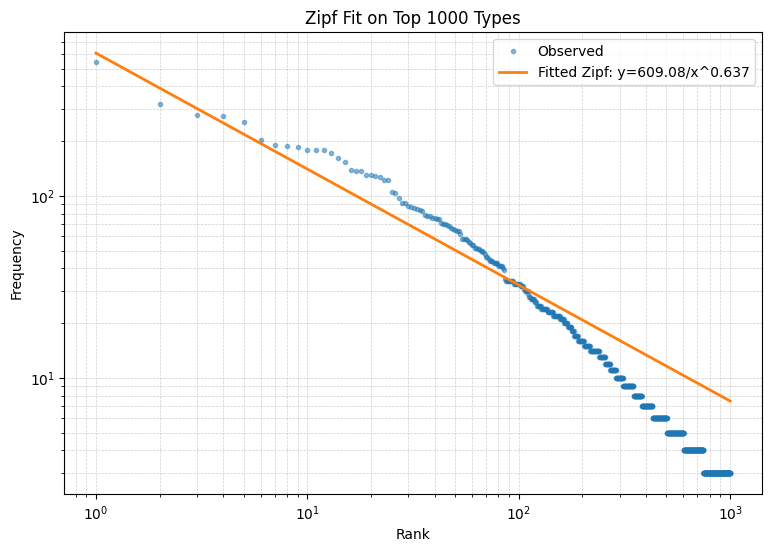

In [75]:

ranks = list(range(1, len(mostcommon_voynich_fdist) + 1))
freqs = [freq for _, freq in mostcommon_voynich_fdist]

p0 = (freqs[0], 1.0)
(params, cov) = scipy.optimize.curve_fit(zipf, ranks, freqs, p0=p0, bounds=(0, np.inf))
a_opt, b_opt = params

freqs_fit = zipf(ranks, a_opt, b_opt)


print(f"Optimal a = {a_opt:.6f}")
print(f"Optimal b = {b_opt:.6f}")

mape = np.mean(np.abs((np.array(freqs) - freqs_fit) / np.array(freqs))) * 100
print(f"MAPE: {mape:.2f}%")

plt.figure(figsize=(9, 6))
plt.plot(ranks, freqs, "o", markersize=3, alpha=0.5, label="Observed")
plt.plot(ranks, freqs_fit, "-", linewidth=2, label=f"Fitted Zipf: y={a_opt:.2f}/x^{b_opt:.3f}")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf Fit on Top 1000 Types")
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.6)
plt.legend()
plt.show()


**4c.** What are your conclusions regarding Voynich's manuscript?  Is it likely to be similar to a real text in an unknown language?  In your answer, consider the values of TTR, the two parameters *a* and *b*, and the fitting of the *y = a / x^b* curve.

**Answer**
If we take into account the curve (thus the a and b parameters) we can see that the Voynich manuscript does follow the Zipft law, but the TTR is much more high so i this regards it balance the answer and make it less obvious. If we need to give an answer is would still say that it is plausibly a real text because it follow Zipf's law, although the b-value is lower meaning voynich has a flatter distribution than gutenberg, further away from classic Zipf's law with b being closer to 1. The MAPE score gets skewed by the low frequency words, making it quite high.

## 5. Testing Zipf's law with BPE tokenization of the book and the manuscript

**5a.** Please install the SentencePiece tokenizer from https://github.com/google/sentencepiece (with `!pip install sentencepiece`).  Please read the "Usage instructions” from the repo, or the ones for the [Python module](https://github.com/google/sentencepiece/blob/master/python/README.md).  Please construct a BPE subword vocabulary (i.e. "train" the model) on your text, of size 1100.  Use here the file you saved in (1d).

In [76]:
def lexical_stats(tokens, tokenizer=nltk.word_tokenize):
    """
    Returns: dict(tokens, types, ttr, vocab)
    - text_or_tokens: raw text (str) OR already-tokenized list
    - tokenizer: used only if input is a str
    """

    vocab = set(tokens)
    n_tokens = len(tokens)
    n_types = len(vocab)
    ttr = (n_types / n_tokens) if n_tokens else 0.0

    return {"tokens": n_tokens, "types": n_types, "ttr": ttr, "vocab": vocab}

In [77]:
# train sentencepiece model from `botchan.txt` and makes `m.model` and `m.vocab`
# `m.vocab` is just a reference. not used in the segmentation.
spm.SentencePieceTrainer.train('--input=Cleaned_sentence.text --model_prefix=bpe --vocab_size=1100 --model_type=bpe')

# makes segmenter instance and loads the model file (m.model)
sp = spm.SentencePieceProcessor(model_file="bpe.model")
sp.load('bpe.model')

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=Cleaned_sentence.text --model_prefix=bpe --vocab_size=1100 --model_type=bpe
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: Cleaned_sentence.text
  input_format: 
  model_prefix: bpe
  model_type: BPE
  vocab_size: 1100
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pa

True

**5b.** Please tokenize your text with this model, and display the number of tokens (i.e. size of vocabulary), the number of types, and the type-to-token ratio (TTR).

In [78]:
# Please write your Python code in this cell and execute it.
with open("Cleaned_sentence.text", encoding="utf-8") as f:
    bpe_tokens = [
        token
        for line in f
        if line.strip()
        for token in sp.encode(line.strip(), out_type=str)
    ]


BPE_stats = lexical_stats(bpe_tokens)

print_stats("Gutenberg BPE",BPE_stats)

Gutenberg BPE -> tokens: 362928, types: 1107, TTR: 0.0031


**5c.** Please fit a Zipf's curve to the book, as tokenized with BPE, and display the two curves on a log-log scale.

Optimal a (Gutenberg BPE) = 15851.357798
Optimal b (Gutenberg BPE) = 0.679647


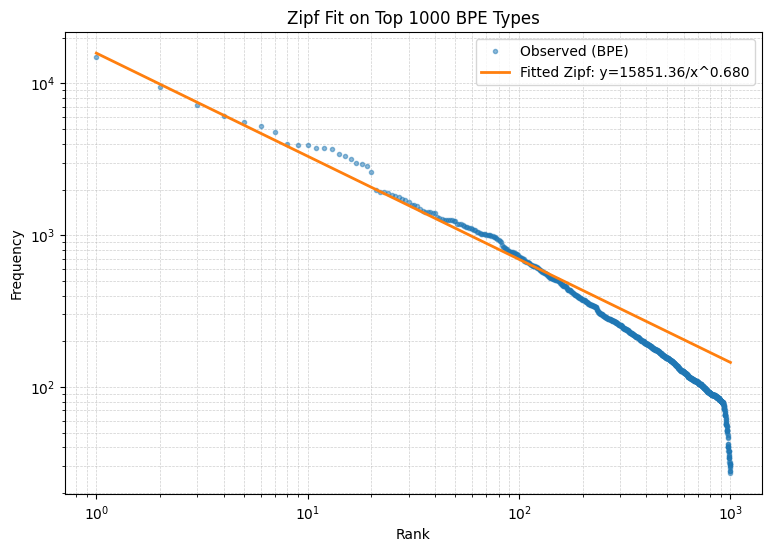

In [79]:
# Please write your Python code in this cell and execute it.

Bpe_text = nltk.Text(bpe_tokens)
Bpe_fdist = nltk.FreqDist(Bpe_text)

top_1000_bpe = Bpe_fdist.most_common(1000)
ranks = list(range(1, len(top_1000_bpe) + 1))
freqs = [freq for _, freq in top_1000_bpe]

# Fit Zipf curve y = a / x^b
p0 = (freqs[0], 1.0)
(params, cov) = scipy.optimize.curve_fit(zipf, ranks, freqs, p0=p0, bounds=(0, np.inf))
a_opt, b_opt = params
freqs_fit = zipf(np.array(ranks), a_opt, b_opt)

print(f"Optimal a (Gutenberg BPE) = {a_opt:.6f}")
print(f"Optimal b (Gutenberg BPE) = {b_opt:.6f}")

# Plot observed vs fitted on log-log scale
plt.figure(figsize=(9, 6))
plt.plot(ranks, freqs, "o", markersize=3, alpha=0.5, label="Observed (BPE)")
plt.plot(ranks, freqs_fit, "-", linewidth=2, label=f"Fitted Zipf: y={a_opt:.2f}/x^{b_opt:.3f}")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf Fit on Top 1000 BPE Types")
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.6)
plt.legend()
plt.show()

**5d.** Please perform the same operations on the Voynich manuscript with a BPE tokenizer build from this text.  Please display the number of tokens, types, TTR, and the fitted Zipf's curve.

In [80]:
# Please write your Python code in this cell and execute it.
spm.SentencePieceTrainer.train('--input=voynich.txt --model_prefix=Voy_bpe --vocab_size=1100 --model_type=bpe')

# makes segmenter instance and loads the model file (m.model)
sp = spm.SentencePieceProcessor(model_file="Voy_bpe.model")
sp.load('Voy_bpe.model')



sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=voynich.txt --model_prefix=Voy_bpe --vocab_size=1100 --model_type=bpe
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: voynich.txt
  input_format: 
  model_prefix: Voy_bpe
  model_type: BPE
  vocab_size: 1100
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1
  u

True

ial_privacy_noise_level: 0
  differential_privacy_clipping_threshold: 0
}
normalizer_spec {
  name: nmt_nfkc
  add_dummy_prefix: 1
  remove_extra_whitespaces: 1
  escape_whitespaces: 1
  normalization_rule_tsv: 
}
denormalizer_spec {}
trainer_interface.cc(355) LOG(INFO) SentenceIterator is not specified. Using MultiFileSentenceIterator.
trainer_interface.cc(186) LOG(INFO) Loading corpus: voynich.txt
trainer_interface.cc(411) LOG(INFO) Loaded all 21029 sentences
trainer_interface.cc(427) LOG(INFO) Adding meta_piece: <unk>
trainer_interface.cc(427) LOG(INFO) Adding meta_piece: <s>
trainer_interface.cc(427) LOG(INFO) Adding meta_piece: </s>
trainer_interface.cc(432) LOG(INFO) Normalizing sentences...
trainer_interface.cc(541) LOG(INFO) all chars count=111234
trainer_interface.cc(552) LOG(INFO) Done: 99.9533% characters are covered.
trainer_interface.cc(562) LOG(INFO) Alphabet size=41
trainer_interface.cc(563) LOG(INFO) Final character coverage=0.999533
trainer_interface.cc(594) LOG(INFO) 

Optimal a (Voynich BPE) = 5637.270233
Optimal b (Voynich BPE) = 0.915683


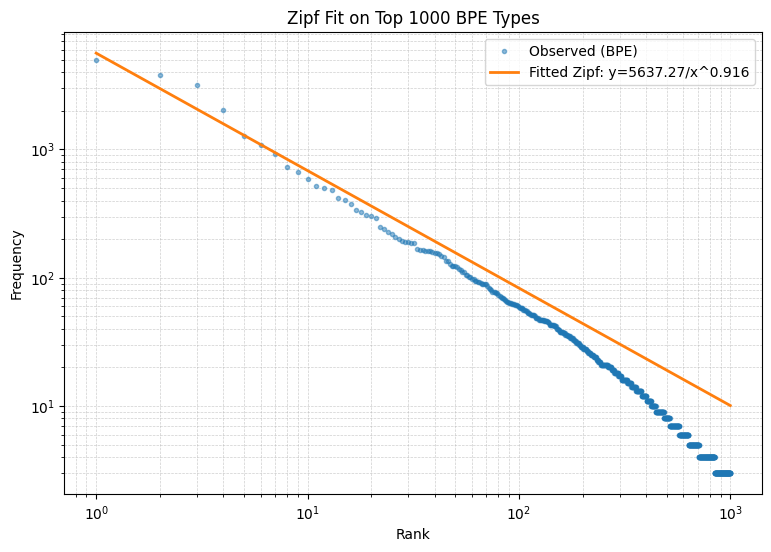

In [81]:
with open("voynich.txt", encoding="utf-8") as f:
    Voy_bpe_tokens = [token 
                     for line in f
                     if line.strip()
                     for token in sp.encode(line.strip(), out_type=str)
    ]



Voy_Bpe_text = nltk.Text(Voy_bpe_tokens)
Voy_Bpe_fdist = nltk.FreqDist(Voy_Bpe_text)

top_1000_bpe = Voy_Bpe_fdist.most_common(1000)
ranks = list(range(1, len(top_1000_bpe) + 1))
freqs = [freq for _, freq in top_1000_bpe]

# Fit Zipf curve y = a / x^b
p0 = (freqs[0], 1.0)
(params, cov) = scipy.optimize.curve_fit(zipf, ranks, freqs, p0=p0, bounds=(0, np.inf))
a_opt, b_opt = params
freqs_fit = zipf(np.array(ranks), a_opt, b_opt)

print(f"Optimal a (Voynich BPE) = {a_opt:.6f}")
print(f"Optimal b (Voynich BPE) = {b_opt:.6f}")

# Plot observed vs fitted on log-log scale
plt.figure(figsize=(9, 6))
plt.plot(ranks, freqs, "o", markersize=3, alpha=0.5, label="Observed (BPE)")
plt.plot(ranks, freqs_fit, "-", linewidth=2, label=f"Fitted Zipf: y={a_opt:.2f}/x^{b_opt:.3f}")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf Fit on Top 1000 BPE Types")
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.6)
plt.legend()
plt.show()

In [82]:
Voy_bpe_stats = lexical_stats(Voy_bpe_tokens)
print_stats("Voynich BPE", Voy_bpe_stats)

Voynich BPE -> tokens: 43717, types: 1113, TTR: 0.0255


**5e.** Please conclude: when using BPE, does the Voynich manuscript exhibit similar properties of token frequency as a real text?  Are the differences larger or smaller when using BPE then when using word-based tokenization ?

**Answer** : 
When using BPE the TTR is still much higher for Voynich than the Gutenberg text, as it was with word level tokenization. This is mostly because Voynich is a much shorter text and this thus doesn't provide any useful information. 

However, when using BPE the b-value for Voynich goes from 0.64 to 0.92, making it more aligned with Zipf's law, which would typically mean a smaller difference to a real text, while the Gutenberg text's b-value goes slightly down, from 0.79 to 0.68, making the difference between the two texts bigger. 

This is counter to the theory that b-value closer to one corresponds to a real text.



## 6. Analyzing Karpathy's BPE tokenization implementation

Please study the following  [minbpe repository](https://github.com/karpathy/minbpe) first and then answer the following questions by indicating the respective file plus codes lines which answer the question.

**6a.** What pre-processing steps are used before BPE training?

In basic.py, line 25 and 26

**First step** : conversion of text in bytes utf-8 
>>text_bytes = text.encode("utf-8") # raw bytes

**Second step** : conversion of bytes into a list of indentifier 
>> L ids = list(text_bytes) # list of integers in range 0..255


**6b.** What tie-breaking strategy is implemented for pairs with equal count statistics?



To chose the pair with the most frequency he use :
>> pair = max(stats, key=stats.get)

but there is not direct implimentation of a tie-breaker, it's implemented via python because the dictionnary keep the order of insertion, then max return the "first" element max element encountered is this regards.


**6c.** Are single characters contained in the final vocabulary?

Yes. Before the training of BPE the vocabulary already contains 256 basis token, that represent one bytes each. 
>>vocab = {idx: bytes([idx]) for idx in range(256)}

**6d.** How are out-of-vocabulary terms treated?

When the encode() receive a text : 
>>text_bytes = text.encode("utf-8")
>>ids = list(text_bytes)

the texte is beforehand cutted into individual bytes. Then the tokenizer (BPE) try to represent the sequence of bytes given with the "learned merged word" that he learned during training. If not he do it with the basic bytes. 

the stop condition is : 
>> if  pair not in self.merges:
    break

So for an unknow term it's : 
    - cut into bytes
    - tokenizer merge the part he know from his training 
    - the unknow part are let in "basic bytes forms" 

So actually there are no out-of-vocabulary terms.


## End of AdvNLP Lab 1
Please clean and save the completed notebook, and upload it to Moodle.